In [1]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

In [2]:
base_path = "../data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/"

flair = nib.load(base_path + "BraTS20_Training_001_flair.nii").get_fdata()
t1 = nib.load(base_path + "BraTS20_Training_001_t1.nii").get_fdata()
t1ce = nib.load(base_path + "BraTS20_Training_001_t1ce.nii").get_fdata()
t2 = nib.load(base_path + "BraTS20_Training_001_t2.nii").get_fdata()
seg = nib.load(base_path + "BraTS20_Training_001_seg.nii").get_fdata()

print("Shape:", flair.shape)

Shape: (240, 240, 155)


In [3]:
def extract_patch(volume, size=128):
    
    x, y, z = volume.shape
    
    cx, cy, cz = x//2, y//2, z//2
    
    half = size // 2
    
    patch = volume[
        cx-half:cx+half,
        cy-half:cy+half,
        cz-half:cz+half
    ]
    
    return patch

In [4]:
patch = extract_patch(flair, size=128)

print("Patch shape:", patch.shape)

Patch shape: (128, 128, 128)


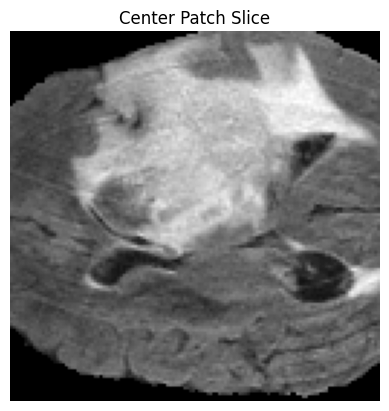

In [5]:
slice_index = patch.shape[2] // 2

plt.imshow(patch[:, :, slice_index], cmap="gray")
plt.title("Center Patch Slice")
plt.axis("off")
plt.show()

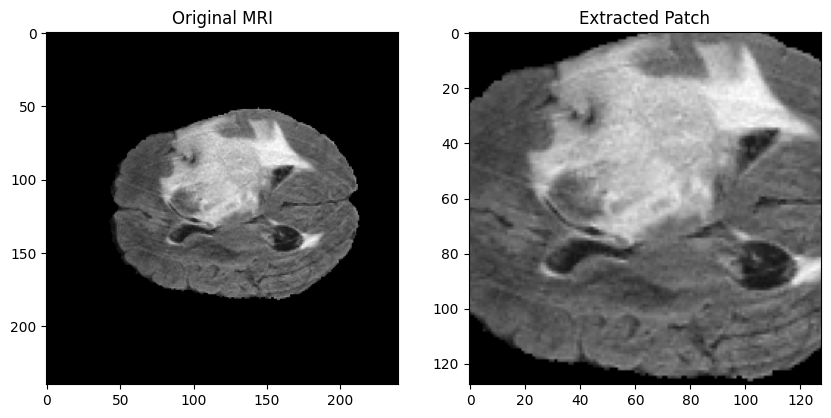

In [6]:
orig_slice = flair.shape[2] // 2

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(flair[:, :, orig_slice], cmap="gray")
plt.title("Original MRI")

plt.subplot(1,2,2)
plt.imshow(patch[:, :, slice_index], cmap="gray")
plt.title("Extracted Patch")

plt.show()

In [7]:
# Find tumor voxels
tumor_voxels = np.where(seg > 0)
x, y, z = tumor_voxels

print("Tumor voxels:", len(x))

# Center of tumor
cx = x[len(x)//2]
cy = y[len(y)//2]
cz = z[len(z)//2]

# Patch size
size = 128
half = size // 2

Tumor voxels: 211979


In [8]:
tumor_patch = flair[
    cx-half:cx+half,
    cy-half:cy+half,
    cz-half:cz+half
]

seg_patch = seg[
    cx-half:cx+half,
    cy-half:cy+half,
    cz-half:cz+half
]

print("Tumor patch shape:", tumor_patch.shape)

Tumor patch shape: (128, 128, 128)


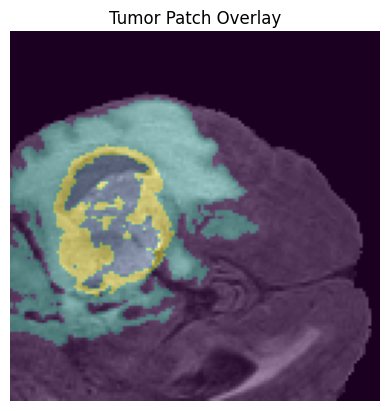

In [9]:
slice_index = tumor_patch.shape[2] // 2

plt.imshow(tumor_patch[:, :, slice_index], cmap="gray")
plt.imshow(seg_patch[:, :, slice_index], alpha=0.4)

plt.title("Tumor Patch Overlay")
plt.axis("off")
plt.show()

In [10]:
multi_patch = np.stack([
    extract_patch(flair, size=128),
    extract_patch(t1, size=128),
    extract_patch(t1ce, size=128),
    extract_patch(t2, size=128)
], axis=0)

print("Multi-modal patch shape:", multi_patch.shape)

Multi-modal patch shape: (4, 128, 128, 128)


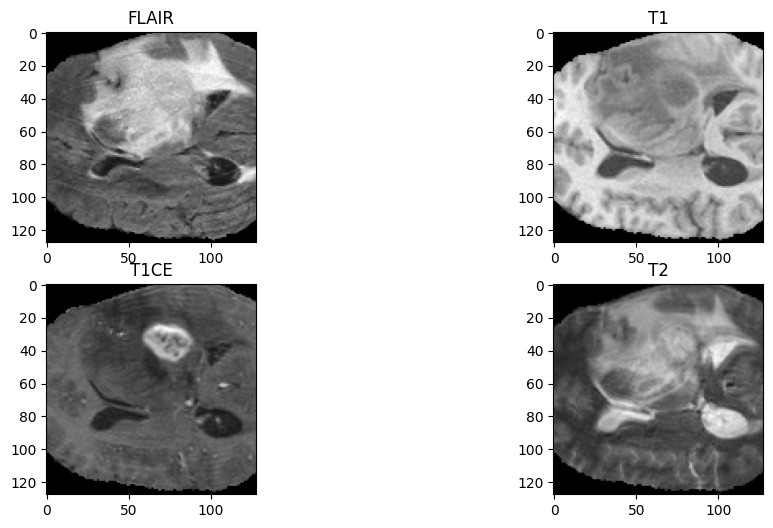

In [11]:
slice_index = 64

plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.imshow(multi_patch[0, :, :, slice_index], cmap="gray")
plt.title("FLAIR")

plt.subplot(2,2,2)
plt.imshow(multi_patch[1, :, :, slice_index], cmap="gray")
plt.title("T1")

plt.subplot(2,2,3)
plt.imshow(multi_patch[2, :, :, slice_index], cmap="gray")
plt.title("T1CE")

plt.subplot(2,2,4)
plt.imshow(multi_patch[3, :, :, slice_index], cmap="gray")
plt.title("T2")

plt.show()